# Verification: Plane Poiseuille Flow

This notebook verifies the solver accuracy by simulating gravity-driven flow between parallel plates (Plane Poiseuille Flow).

We create a periodic domain with a solid slab in the center. The fluid wraps around the periodic boundaries at $y=0$ and $y=L$, effectively creating a channel of height $H = L - t_{slab}$.

## Analytical Solution
For a channel of height $H$ driven by body force $g_x$:
$$ U_{avg} = \frac{g H^2}{12 \nu} $$
$$ U_{max} = \frac{1.5}{U_{avg}} = \frac{g H^2}{8 \nu} $$
$$ u(y') = U_{max} \left( 1 - \left( \frac{2 y'}{H} \right)^2 \right) $$
where $y'$ is the distance from the channel center (which is at global $y=0$ in our periodic setup).

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Add build directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../build')))
import pnm_backend

os.makedirs('output', exist_ok=True)

In [2]:
def generate_slab_sdf(nx, ny, nz, L, slab_thickness):
    # Anisotropic resolution
    # Domain size L is cubic for now, so L_x=L_y=L_z = L
    # If L were a vector, we'd do dx = Lx/nx, etc.
    dx = L / nx
    dy = L / ny
    dz = L / nz
    
    x = np.linspace(0, L, nx, endpoint=False) + 0.5 * dx
    y = np.linspace(0, L, ny, endpoint=False) + 0.5 * dy
    z = np.linspace(0, L, nz, endpoint=False) + 0.5 * dz
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    yc = L/2
    # Distance to slab surface (walls at yc +/- t/2)
    # Positive outside slab (fluid), Negative inside slab (solid)
    # Actually pnm_backend assumes SDF < 0 is SOLID.
    # So inside slab (y near yc), we want dist < 0.
    # dist = |y - yc| - t/2
    dist = np.abs(Y - yc) - slab_thickness/2.0
    
    return dist.ravel(order='F').astype(np.float32), (dx, dy, dz)

def get_analytical_profile(y_coords, L, H, g, nu):
    # y_coords: global y positions [0, L]
    # Fluid channel is wrapped around y=0/L.
    # Slab is at [L/2 - t/2, L/2 + t/2].
    # Channel center is effectively at y=0 (or y=L).
    # We map global y to channel coordinate y' in [-H/2, H/2].
    
    # If y < L/2: It is the 'bottom' half (connected to y=0). y' = y
    # If y > L/2: It is the 'top' half (connected to y=L). y' = y - L
    # Note: Walls are at y = (L-H)/2 and y = (L+H)/2 ? No.
    # Slab t = L - H. Slab center L/2.
    # Walls are at L/2 - t/2 = L/2 - (L-H)/2 = H/2.
    # And L/2 + t/2 = L - H/2.
    # So fluid is in [0, H/2] and [L - H/2, L].
    
    u_prof = np.zeros_like(y_coords)
    U_max = (g * H**2) / (8.0 * nu)
    
    for i, y in enumerate(y_coords):
        # Transform to centered coordinate y_prime
        if y < L/2:
            y_prime = y
        else:
            y_prime = y - L
            
        # Check if in fluid
        if abs(y_prime) <= H/2:
            u_prof[i] = U_max * (1.0 - (2.0 * y_prime / H)**2)
        else:
            u_prof[i] = 0.0 # In solid
            
    return u_prof

def save_vti(filename, res_int3, spacing_float3, u, v, w, p):
    """Saves field data to VTI format."""
    nx, ny, nz = res_int3.x, res_int3.y, res_int3.z
    dx, dy, dz = spacing_float3.x, spacing_float3.y, spacing_float3.z
    
    # Interpolate staggered velocity to cell centers for correct visualization
    # u_stag(i,j,k) is at i-1/2. u_cc(i) = 0.5 * (u(i) + u(i+1))
    
    # Reshape using Fortran order to get (Nx, Ny, Nz) shape [x, y, z]
    # This interprets the linear buffer (X-fast) correctly into [i,j,k]
    u_grid = u.reshape((nx, ny, nz), order='F')
    v_grid = v.reshape((nx, ny, nz), order='F')
    w_grid = w.reshape((nx, ny, nz), order='F')
    
    # Check periodicity logic: pnm_backend uses periodic wrapping
    # With shape [x, y, z]:
    # Axis 0 is X
    # Axis 1 is Y
    # Axis 2 is Z
    u_cc = 0.5 * (u_grid + np.roll(u_grid, -1, axis=0))
    v_cc = 0.5 * (v_grid + np.roll(v_grid, -1, axis=1))
    w_cc = 0.5 * (w_grid + np.roll(w_grid, -1, axis=2))
    
    # Flatten back to X-fast 1D streams for VTI writing
    u_flat = u_cc.ravel(order='F')
    v_flat = v_cc.ravel(order='F')
    w_flat = w_cc.ravel(order='F')

    with open(filename, 'w') as f:
        f.write('<?xml version="1.0"?>\n')
        f.write('<VTKFile type="ImageData" version="0.1" byte_order="LittleEndian">\n')
        f.write(f'  <ImageData WholeExtent="0 {nx-1} 0 {ny-1} 0 {nz-1}" Origin="0 0 0" Spacing="{dx} {dy} {dz}">\n')
        f.write(f'    <Piece Extent="0 {nx-1} 0 {ny-1} 0 {nz-1}">\n')
        f.write('      <PointData Scalars="Pressure" Vectors="Velocity">\n')
        
        f.write('        <DataArray type="Float32" Name="Velocity" NumberOfComponents="3" format="ascii">\n')
        for i in range(len(u_flat)):
            f.write(f"{u_flat[i]} {v_flat[i]} {w_flat[i]} ")
        f.write('\n        </DataArray>\n')
        
        f.write('        <DataArray type="Float32" Name="u" NumberOfComponents="1" format="ascii">\n')
        for val in u_flat:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')

        f.write('        <DataArray type="Float32" Name="v" NumberOfComponents="1" format="ascii">\n')
        for val in v_flat:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')

        f.write('        <DataArray type="Float32" Name="w" NumberOfComponents="1" format="ascii">\n')
        for val in w_flat:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')
        
        f.write('        <DataArray type="Float32" Name="Pressure" NumberOfComponents="1" format="ascii">\n')
        for val in p:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')
        
        f.write('      </PointData>\n')
        f.write('    </Piece>\n')
        f.write('  </ImageData>\n')
        f.write('</VTKFile>\n')
    print(f"Saved {filename}")

In [43]:
def run_poiseuille(res_tuple, save_output=False, filename=None):
    nx, ny, nz = res_tuple
    L = 1.0
    slab_thickness = 0.2
    H = L - slab_thickness
    
    sdf_values, spacing = generate_slab_sdf(nx, ny, nz, L, slab_thickness)
    dx, dy, dz = spacing
    
    sdf_data = pnm_backend.SDFData(
        sdf_values, 
        pnm_backend.int3(nx, ny, nz),
        pnm_backend.float3(0,0,0),
        pnm_backend.float3(dx, dy, dz)
    )
    solver = pnm_backend.CFDSolver(
        pnm_backend.int3(nx, ny, nz), 
        pnm_backend.float3(dx, dy, dz)
    )
    solver.initialize(sdf_data)
    
    rho = 1.0
    nu = 0.01
    g_x = 1.0
    solver.set_body_force(pnm_backend.float3(g_x, 0, 0))
    solver.set_rho(rho)
    solver.set_nu(nu)
    
    # Time step limited by smallest cell size
    #solver.set_cfl(0.5)
    solver.set_pressure_solver_params(10, 1e-16)
    solver.set_velocity_solver_params(int(ny*ny), 1e-16)
    
    print(f"Running Grid={nx}x{ny}x{nz}...")
    for i in range(2):
        solver.step_implicit(100.0)
        # Simple fixed steps or convergence check
        if i > 0 and i % 100 == 0:
            # Minimal output to keep notebook clean
            pass
            
    # Extract Profile
    # Get full U field
    u_flat = np.array(solver.get_u())
    u_grid = u_flat.reshape((nx, ny, nz), order='F') # [x, y, z]
    
    # Extract line profile at mid-X, mid-Z, along Y
    ix = nx // 2
    iz = nz // 2
    u_profile = u_grid[ix, :, iz]
    
    # Analytical Profile
    # Y coordinates correspond to cell centers in Y direction
    y_coords = np.linspace(0, L, ny, endpoint=False) + 0.5 * dy
    
    u_ana = get_analytical_profile(y_coords, L, H, g_x, nu)
    
    if save_output and filename:
        v = np.array(solver.get_v())
        w = np.array(solver.get_w())
        p = np.array(solver.get_p())
        save_vti(filename, pnm_backend.int3(nx, ny, nz), pnm_backend.float3(dx, dy, dz), u_flat, v, w, p)
    
    return y_coords, u_profile, u_ana

Running Grid=4x16x4...
IBM Geometry Updated.
  Pressure/Center: 32
  U-Face: 32
  V-Face: 32
  W-Face: 32
Saved output/poiseuille_4x16x4.vti
Running Grid=4x32x4...
IBM Geometry Updated.
  Pressure/Center: 32
  U-Face: 32
  V-Face: 32
  W-Face: 32
Saved output/poiseuille_4x32x4.vti


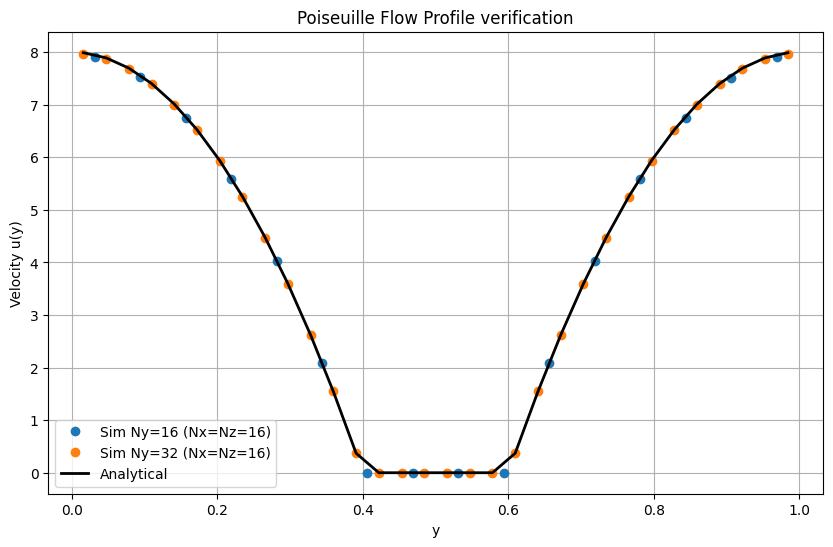

In [44]:
resolutions = [(4, 16, 4), (4, 32, 4)]
results = {}

plt.figure(figsize=(10, 6))

for res in resolutions:
    nx, ny, nz = res
    filename = f'output/poiseuille_{nx}x{ny}x{nz}.vti'
    y, u_sim, u_ana = run_poiseuille(res, save_output=True, filename=filename)
    results[res] = (y, u_sim, u_ana)
    
    plt.plot(y, u_sim, 'o', label=f'Sim Ny={ny} (Nx=Nz=16)')
    if res == resolutions[-1]: # Plot analyt only once or for best res
        plt.plot(y, u_ana, 'k-', linewidth=2, label='Analytical')

plt.xlabel('y')
plt.ylabel('Velocity u(y)')
plt.title('Poiseuille Flow Profile verification')
plt.legend()
plt.grid(True)
plt.savefig('output/poiseuille_profile.png')
plt.show()